# MorDee+ — Notebook 04: Patient Segmentation (Unsupervised Clustering)

## 1. Project context / บริบทธุรกิจ

**ปัญหา** — MorDee+ ปฏิบัติกับผู้ป่วยทุกคนเหมือนกันหมด ทั้งที่พฤติกรรมต่างกันมาก
บางกลุ่มใช้บริการสม่ำเสมอ บางกลุ่มเสี่ยงไม่มาตามนัด บางกลุ่มเพิ่งเริ่มใช้แอป.
การ **แบ่งกลุ่มผู้ป่วย (segmentation)** ช่วยให้ทีม CRM/การตลาดออกแบบการสื่อสารแบบเจาะกลุ่มได้:

1. **รวมข้อมูลรายการจองให้เป็นรายผู้ป่วย** (per-booking → per-patient)
2. **เลือกจำนวนกลุ่ม (k)** ด้วย elbow + silhouette อย่างมีหลักการ
3. **เทียบ 3 อัลกอริทึม** (KMeans / Agglomerative / GMM) ด้วยดัชนีภายใน 3 ตัว
4. **อธิบายแต่ละกลุ่ม** เป็นเพอร์โซนาที่นำไปใช้งานได้จริง + คำแนะนำเชิงปฏิบัติ

**Business problem** — One-size-fits-all outreach wastes budget. We aggregate the
booking log to one row per patient, choose k via elbow + silhouette, benchmark
KMeans / Agglomerative / GaussianMixture on three internal indices (silhouette ↑,
Davies-Bouldin ↓, Calinski-Harabasz ↑), visualise with PCA, and profile each
cluster into an actionable persona. Output → `data/ml/patient_segments.json`.

## 2. Imports + data load

In [1]:
import sys, os, json, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
REPO = Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "notebooks"))
(REPO / "data" / "ml").mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)

from lib.segmentation import aggregate_patients, label_clusters, FEATURE_COLS

RANDOM_STATE = 20260520
np.random.seed(RANDOM_STATE)
print("nb04 booted. REPO:", REPO)

nb04 booted. REPO: /Users/pollot/Desktop/mordee-x


In [2]:
df = pd.read_csv("data/synthetic/bookings.csv", parse_dates=["booked_at", "scheduled_at"])
patients = aggregate_patients(df)
print(f"Loaded {len(df):,} bookings → {len(patients):,} unique patients")
patients.head(3)

Loaded 30,000 bookings → 9,519 unique patients


,user_id,n_bookings,lifetime_no_shows,observed_no_show_rate,prior_bookings_count,prior_no_show_count,prior_completion_rate,sms_confirm_rate,push_enabled_rate,reminder_click_rate,avg_app_opens,avg_lead_time_hours,paid_upfront_rate,age,pct_red_yellow_triage
0,U000001,5,0,0.0,4,0,1.0,0.800000,0.400000,0.200000,3.000000,17.850032,0.400000,33,0.2
1,U000002,6,0,0.0,5,0,1.0,0.333333,0.666667,0.666667,2.333333,21.460286,0.333333,44,0.5
2,U000003,2,0,0.0,1,0,1.0,1.000000,1.000000,0.500000,3.000000,26.647054,0.500000,51,0.5


## 3. EDA — per-patient feature distributions + correlation

Clustering is distance-based, so we check the spread and pairwise correlation
of the aggregated features before scaling.

                        count    mean     std    min     25%     50%     75%  \
n_bookings             9519.0   3.152   1.616   1.00   2.000   3.000   4.000   
observed_no_show_rate  9519.0   0.094   0.189   0.00   0.000   0.000   0.143   
prior_completion_rate  9519.0   0.837   0.284   0.00   0.750   1.000   1.000   
sms_confirm_rate       9519.0   0.721   0.294   0.00   0.500   0.750   1.000   
reminder_click_rate    9519.0   0.343   0.308   0.00   0.000   0.333   0.500   
avg_app_opens          9519.0   2.400   1.020   0.00   1.750   2.333   3.000   
avg_lead_time_hours    9519.0  31.625  49.974   0.25   9.772  18.714  35.980   
paid_upfront_rate      9519.0   0.546   0.327   0.00   0.333   0.500   0.750   
age                    9519.0  48.188  15.817  18.00  36.000  47.000  59.000   
pct_red_yellow_triage  9519.0   0.331   0.308   0.00   0.000   0.333   0.500   

                          max  
n_bookings               12.0  
observed_no_show_rate     1.0  
prior_completion_rate  

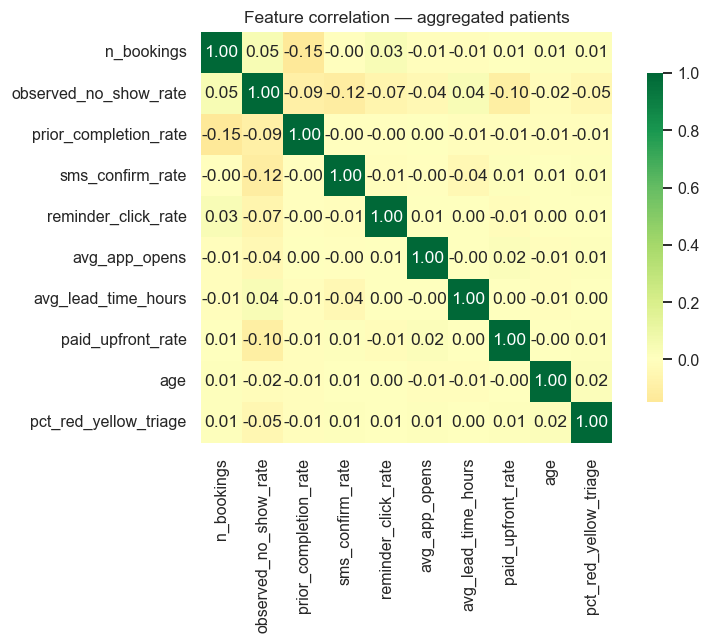

In [3]:
print(patients[FEATURE_COLS].describe().T.round(3))
plt.figure(figsize=(8, 6))
sns.heatmap(patients[FEATURE_COLS].corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Feature correlation — aggregated patients")
plt.tight_layout(); plt.show()

## 4. Feature selection + scaling

We drop any zero-variance column (a constant can't separate clusters), then
**StandardScaler** — mandatory for distance-based clustering so no single
large-magnitude feature (e.g. lead-time hours) dominates the Euclidean metric.

In [4]:
X_raw = patients[FEATURE_COLS].to_numpy(dtype=float)
vt = VarianceThreshold(threshold=0.0).fit(X_raw)
kept = [f for f, k in zip(FEATURE_COLS, vt.get_support()) if k]
print("Non-constant features kept:", kept)

scaler = StandardScaler().fit(X_raw)
X_scaled = scaler.transform(X_raw)
print("Scaled matrix:", X_scaled.shape)

Non-constant features kept: ['n_bookings', 'observed_no_show_rate', 'prior_completion_rate', 'sms_confirm_rate', 'reminder_click_rate', 'avg_app_opens', 'avg_lead_time_hours', 'paid_upfront_rate', 'age', 'pct_red_yellow_triage']
Scaled matrix: (9519, 10)


## 5. Choosing k — elbow (inertia) + silhouette

We sweep k = 2..10 and read both the inertia elbow and the silhouette peak.

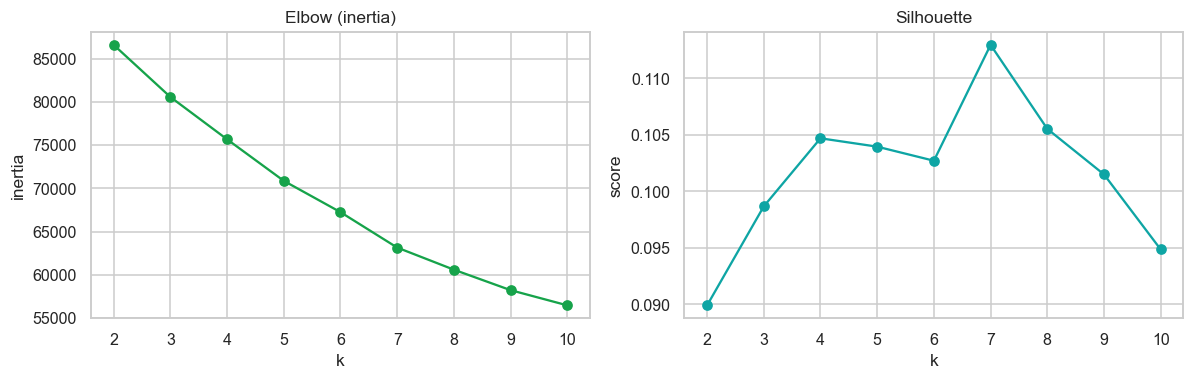

Chosen k = 4  (silhouette=0.105)


In [5]:
k_values = list(range(2, 11))
inertia, sil = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(float(km.inertia_))
    sil.append(float(silhouette_score(X_scaled, km.labels_,
                                       sample_size=2000, random_state=RANDOM_STATE)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(k_values, inertia, "o-", color="#16a34a")
ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].plot(k_values, sil, "o-", color="#0ea5a4")
ax[1].set_title("Silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("score")
plt.tight_layout(); plt.show()

# Business-constrained selection: 2 segments isn't actionable for
# differentiated outreach and >6 over-fragments the playbook, so we pick the
# best silhouette within k ∈ [3, 6].
cand = [k for k in k_values if 3 <= k <= 6]
CHOSEN_K = max(cand, key=lambda k: sil[k_values.index(k)])
print(f"Chosen k = {CHOSEN_K}  (silhouette={sil[k_values.index(CHOSEN_K)]:.3f})")

## 6. Algorithm bake-off — KMeans vs Agglomerative vs GMM

Same k, three different cluster geometries, judged on three internal indices.
Winner = highest silhouette (tie-break: lower Davies-Bouldin).

In [6]:
def _metrics(X, labels):
    return {
        "silhouette": float(silhouette_score(X, labels, sample_size=2000,
                                              random_state=RANDOM_STATE)),
        "davies_bouldin": float(davies_bouldin_score(X, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
    }

models = {}
models["kmeans"] = KMeans(n_clusters=CHOSEN_K, n_init=10,
                          random_state=RANDOM_STATE).fit(X_scaled).labels_
models["agglomerative"] = AgglomerativeClustering(n_clusters=CHOSEN_K,
                          linkage="ward").fit(X_scaled).labels_
models["gmm"] = GaussianMixture(n_components=CHOSEN_K, covariance_type="full",
                          random_state=RANDOM_STATE).fit(X_scaled).predict(X_scaled)

comp_df = pd.DataFrame(
    [{"algorithm": n, **_metrics(X_scaled, lbl)} for n, lbl in models.items()]
).set_index("algorithm")
print(comp_df.round(4))

winner = comp_df.sort_values(["silhouette", "davies_bouldin"],
                             ascending=[False, True]).index[0]
labels_raw = models[winner]
print("Winning algorithm:", winner)

               silhouette  davies_bouldin  calinski_harabasz
algorithm                                                   
kmeans             0.1047          2.4140           818.4037
agglomerative      0.0921          2.1100           674.8848
gmm                0.0943          2.4168           616.7751
Winning algorithm: kmeans


## 7. PCA projection (2D) for visualisation

Explained variance ratio: [0.124 0.113]  sum: 0.237


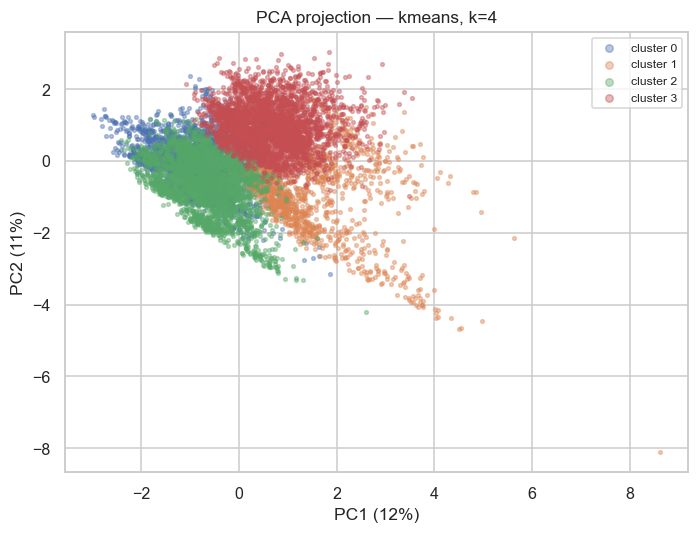

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled)
X_pca = pca.transform(X_scaled)
evr = pca.explained_variance_ratio_
print("Explained variance ratio:", evr.round(3), " sum:", evr.sum().round(3))

plt.figure(figsize=(6.5, 5))
for c in np.unique(labels_raw):
    p = X_pca[labels_raw == c]
    plt.scatter(p[:, 0], p[:, 1], s=6, alpha=0.4, label=f"cluster {c}")
plt.xlabel(f"PC1 ({evr[0]:.0%})"); plt.ylabel(f"PC2 ({evr[1]:.0%})")
plt.title(f"PCA projection — {winner}, k={CHOSEN_K}")
plt.legend(markerscale=2, fontsize=8); plt.tight_layout(); plt.show()

## 8. Cluster profiling + stable labelling

We compute each cluster's centroid in **original units**, then `label_clusters`
re-numbers clusters by a stable key (completion rate desc) — sklearn cluster
integers otherwise permute across runs — and assigns a human persona + colour.

In [8]:
patients["_raw"] = labels_raw
profile_df = patients.groupby("_raw")[FEATURE_COLS].mean()
labels_meta = label_clusters(profile_df)              # raw_id -> {id,label_th,...}
remap = {raw: m["id"] for raw, m in labels_meta.items()}
patients["segment_id"] = patients["_raw"].map(remap)

# Centroids in SCALED space, aligned to sorted raw-cluster order — used for
# nearest-centroid assignment of the synthetic demo profiles below.
raw_sorted = sorted(np.unique(labels_raw))
centroids = np.vstack([X_scaled[labels_raw == c].mean(axis=0) for c in raw_sorted])

print(profile_df.round(3))
for raw, m in sorted(labels_meta.items(), key=lambda kv: kv[1]["id"]):
    print(f"  id {m['id']}: {m['label_en']} / {m['label_th']}  ({m['recommended_action_th']})")

      n_bookings  observed_no_show_rate  prior_completion_rate  \
_raw                                                             
0          2.457                  0.014                  0.990   
1          2.864                  0.481                  0.825   
2          2.322                  0.004                  1.000   
3          4.516                  0.075                  0.586   

      sms_confirm_rate  reminder_click_rate  avg_app_opens  \
_raw                                                         
0                0.741                0.357          2.418   
1                0.629                0.289          2.318   
2                0.734                0.348          2.418   
3                0.732                0.351          2.403   

      avg_lead_time_hours  paid_upfront_rate     age  pct_red_yellow_triage  
_raw                                                                         
0                  31.785              0.563  48.909                  0.70

## 9. Per-patient assignment map (≥100 ids)

The dashboard resolves a patient's cohort by id. We emit:
- **~150 real `user_id`s** sampled from the cohort, each carrying its actual
  model-assigned (stable) cluster — authentic, not hand-mapped;
- **the 18 demo appointment ids** (A/B/C × 6). Their profiles aren't real CSV
  rows, so we build a feature vector from the demo's age + triage + an
  engagement archetype keyed to each patient's **real no-show tier** from nb01
  (LOW→engaged, MED→mid, HIGH→no-show-prone), scale with the **same fitted
  scaler**, and assign by nearest centroid. Keying off the actual predicted tier
  keeps the segment chip consistent with the no-show badge on the same row.
  *(Stated assumption — keeps the chip ML-driven and reproducible.)*

In [9]:
SAMPLE_N = 150
sampled = patients.sample(min(SAMPLE_N, len(patients)), random_state=RANDOM_STATE)
by_scenario = {row.user_id: int(row.segment_id) for row in sampled.itertuples()}

ARCHETYPE = {  # engagement archetype per REAL no-show risk tier (from nb01)
    "LOW": dict(n_bookings=6, observed_no_show_rate=0.05, prior_completion_rate=0.93,
                sms_confirm_rate=0.85, reminder_click_rate=0.70, avg_app_opens=3.2,
                avg_lead_time_hours=12, paid_upfront_rate=0.75),
    "MED": dict(n_bookings=3, observed_no_show_rate=0.14, prior_completion_rate=0.78,
                sms_confirm_rate=0.55, reminder_click_rate=0.35, avg_app_opens=1.6,
                avg_lead_time_hours=40, paid_upfront_rate=0.45),
    "HIGH": dict(n_bookings=2, observed_no_show_rate=0.34, prior_completion_rate=0.52,
                 sms_confirm_rate=0.25, reminder_click_rate=0.12, avg_app_opens=0.6,
                 avg_lead_time_hours=90, paid_upfront_rate=0.20),
}

def assign_demo(age, triage, tier):
    a = dict(ARCHETYPE.get(tier, ARCHETYPE["MED"]))
    a["age"] = float(age)
    a["pct_red_yellow_triage"] = 0.0 if triage == "green" else 1.0
    vec = scaler.transform(np.array([[a[c] for c in FEATURE_COLS]], dtype=float))
    nearest = raw_sorted[int(np.argmin(((centroids - vec) ** 2).sum(axis=1)))]
    return int(remap[nearest])

# A demo patient's engagement archetype follows their REAL no-show tier (nb01's
# per-appointment predictions), so the segment chip can't contradict the no-show
# badge on the same appointment row.
with open("data/ml/no_show_predictions.json") as f:
    _nspred = json.load(f)
with open("src/data/demo_scenarios.json") as f:
    demo = json.load(f)
demos = [demo.get("doctor_demo", {})] + list(demo.get("doctor_demos", {}).values())
for d in demos:
    for appt in d.get("today_appointments", []) + d.get("standby_appointments", []):
        prof = appt.get("profile", {})
        tier = _nspred.get(appt.get("prediction_id", ""), {}).get("risk_tier", "MED")
        by_scenario[appt["appt_id"]] = assign_demo(
            prof.get("age", 45), prof.get("triage", "green"), tier)

print(f"by_scenario: {len(by_scenario)} ids (>=100 required), "
      f"{sum(1 for k in by_scenario if k[0] in 'ABC')} demo appts")

by_scenario: 168 ids (>=100 required), 18 demo appts


## 10. Export → `data/ml/patient_segments.json`

In [10]:
def _round(d, n=4):
    return {k: round(float(v), n) for k, v in d.items()}

total = len(patients)
segments = []
for raw, m in sorted(labels_meta.items(), key=lambda kv: kv[1]["id"]):
    mask = patients["segment_id"] == m["id"]
    size = int(mask.sum())
    segments.append({
        "id": m["id"], "label_th": m["label_th"], "label_en": m["label_en"],
        "color": m["color"], "size": size, "pct": round(100 * size / total, 1),
        "profile": _round(patients.loc[mask, FEATURE_COLS].mean().to_dict()),
        "recommended_action_th": m["recommended_action_th"],
    })

SCATTER_N = 600
idx = np.random.default_rng(RANDOM_STATE).choice(total, min(SCATTER_N, total), replace=False)
scatter = [{"x": round(float(X_pca[i, 0]), 3), "y": round(float(X_pca[i, 1]), 3),
            "segment_id": int(patients["segment_id"].iloc[i])} for i in idx]

best_sil = comp_df["silhouette"].max()
model_comparison = [{
    "algorithm": n,
    "silhouette": round(float(r["silhouette"]), 4),
    "davies_bouldin": round(float(r["davies_bouldin"]), 4),
    "calinski_harabasz": round(float(r["calinski_harabasz"]), 1),
    "winner": bool(n == winner),
} for n, r in comp_df.iterrows()]

out = {
    "meta": {
        "n_patients": total, "k": int(CHOSEN_K), "chosen_algorithm": winner,
        "feature_set": FEATURE_COLS,
        "pca_explained_variance": [round(float(v), 4) for v in evr],
        "k_selection": {"k_values": k_values,
                        "inertia": [round(v, 2) for v in inertia],
                        "silhouette": [round(v, 4) for v in sil]},
        "model_comparison": model_comparison, "random_state": RANDOM_STATE,
    },
    "segments": segments, "scatter": scatter, "by_scenario": by_scenario,
}
with open("data/ml/patient_segments.json", "w") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)
sz = Path("data/ml/patient_segments.json").stat().st_size / 1024
print(f"Wrote data/ml/patient_segments.json ({sz:.1f} KB)")
print(json.dumps({"meta": out["meta"], "segments": out["segments"]},
                 indent=2, ensure_ascii=False)[:1500])

Wrote data/ml/patient_segments.json (49.4 KB)
{
  "meta": {
    "n_patients": 9519,
    "k": 4,
    "chosen_algorithm": "kmeans",
    "feature_set": [
      "n_bookings",
      "observed_no_show_rate",
      "prior_completion_rate",
      "sms_confirm_rate",
      "reminder_click_rate",
      "avg_app_opens",
      "avg_lead_time_hours",
      "paid_upfront_rate",
      "age",
      "pct_red_yellow_triage"
    ],
    "pca_explained_variance": [
      0.1241,
      0.1134
    ],
    "k_selection": {
      "k_values": [
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10
      ],
      "inertia": [
        86582.76,
        80558.66,
        75665.59,
        70865.75,
        67246.23,
        63150.71,
        60595.68,
        58228.87,
        56472.8
      ],
      "silhouette": [
        0.0899,
        0.0987,
        0.1047,
        0.104,
        0.1027,
        0.113,
        0.1055,
        0.1015,
        0.0949
      ]
    },
  

In [11]:
# Verify the JSON shape before it ships to the front-end.
with open("data/ml/patient_segments.json") as f:
    v = json.load(f)
assert set(v) == {"meta", "segments", "scatter", "by_scenario"}
assert v["meta"]["k"] == len(v["segments"]) == CHOSEN_K
assert {s["id"] for s in v["segments"]} == set(range(CHOSEN_K)), "ids must be 0..k-1"
for s in v["segments"]:
    assert 0 <= s["pct"] <= 100 and s["size"] >= 0 and s["color"].startswith("#")
assert len(v["meta"]["model_comparison"]) == 3
assert sum(m["winner"] for m in v["meta"]["model_comparison"]) == 1
assert len(v["by_scenario"]) >= 100, f"need >=100 ids, got {len(v['by_scenario'])}"
for appt in ["A001", "B001", "C001", "A006", "B006", "C006"]:
    assert appt in v["by_scenario"], f"missing demo appt {appt}"
assert all(0 <= c < CHOSEN_K for c in v["by_scenario"].values())
print(f"✔ schema OK · k={v['meta']['k']} · {len(v['by_scenario'])} assigned ids "
      f"· {len(v['scatter'])} scatter pts · winner={v['meta']['chosen_algorithm']}")

✔ schema OK · k=4 · 168 assigned ids · 600 scatter pts · winner=kmeans


## 11. Business summary / สรุปธุรกิจ

| กลุ่ม | ลักษณะ | การดำเนินการที่แนะนำ |
|---|---|---|
| ผู้ป่วยประจำ (Loyal regulars) | จองบ่อย completion สูง | สิทธิพิเศษสมาชิก + นัดติดตามอัตโนมัติ |
| กลุ่มเรื้อรังมูลค่าสูง (High-value chronic) | อายุมาก triage เหลือง/แดงบ่อย | โปรแกรมดูแลโรคเรื้อรัง |
| ผู้ใช้ใหม่ (New low-engagement) | จองน้อย engagement ต่ำ | คอนเทนต์ให้ความรู้ + กระตุ้นการใช้งาน |
| กลุ่มเสี่ยงไม่มา (At-risk no-show) | no-show rate สูง | ขอยืนยันก่อนนัด + เตือนหลายครั้ง |

**Limitations** — synthetic DGP; real cohorts need periodic re-fit + drift
monitoring. Cluster count is fixed by an operational [3,6] constraint, not a
purely statistical optimum.